# Visualización

Como ya hemos mencionado, la visualización es una parte fundamental del proceso de EDA, dado que nos permite presentar nuestros resultados e hipótesis de manera clara, concisa y resumida. En este sentido, hoy revisaremos algunos de los gráficos más utilizados

 - Gráficos de barras, histogramas y variantes
 - Gráficos de dispersión (scatterplot) y variantes
 - Boxplot


In [1]:
# Importar el modulo pyplot y llamarlo plt (convención)
import matplotlib.pyplot as plt

Lo primero que debemos generar es una `figura` que será el gráfico y los `ejes` que tendrán los datos asociados al gráfico, lo cual se realiza de la siguiente forma

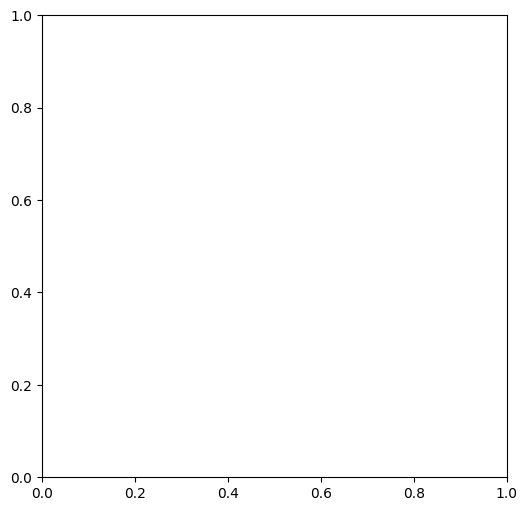

In [2]:
fig, ax = plt.subplots(figsize=(6, 6)) #sharex, sharey, figsize=(8, 8)
plt.show()

Lo anterior crea una figura vacia a la cual debemos llenar con la información que nos interesa graficar. Para ello utilizaremos un dataset que vimos en la clase pasada sobre los precios del S&P future. 

In [3]:
import pandas as pd
Stocks = pd.read_csv('./Data/SP500.csv',index_col = 'date', parse_dates = True)
Stocks.drop(['Unnamed: 0'], axis = 1, inplace = True)
Stocks.sort_index(inplace=True)
Stocks.tail()

,min,max,avg,vol
date,,,,
2019-12-24,3224.0,3229.8,3226.275000,5
2019-12-26,3229.5,3244.0,3236.445455,0
2019-12-27,3237.5,3253.5,3245.381250,7
2019-12-30,3220.0,3242.6,3229.732000,12
2019-12-31,3216.0,3233.0,3226.940000,1


In [4]:
Stocks.head()

,min,max,avg,vol
date,,,,
2000-01-03,1452.0,1496.4,1464.939479,0
2000-01-04,1409.5,1453.5,1434.881533,0
2000-01-05,1387.0,1427.5,1411.066877,0
2000-01-06,1401.0,1425.8,1416.693848,0
2000-01-07,1412.0,1460.5,1434.536222,0


Luego, graficaremos los precios de cierre de la siguiente forma

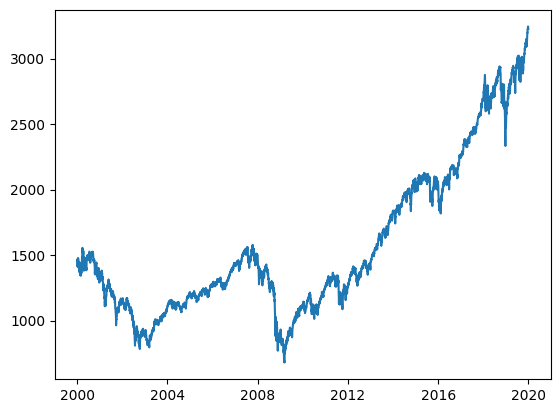

In [5]:
fig, ax = plt.subplots()
ax.plot(Stocks.index, Stocks['avg'])
plt.show()

Y ya tenemos nuestro primer gráfico! Ahora la idea es ir complicando el tipo de gráfico que queremos pero antes revisaremos algunos comandos básicos que nos serviran más adelante

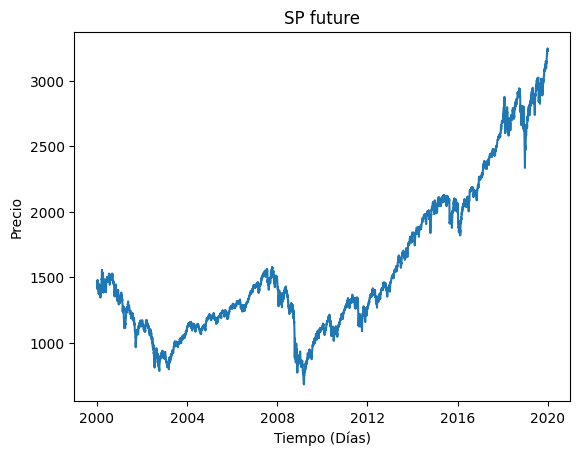

In [6]:
# Nombre de los ejes y titulo
fig, ax = plt.subplots()
ax.plot(Stocks.index, Stocks['avg'])
ax.set_xlabel('Tiempo (Días)')
ax.set_ylabel('Precio')
ax.set_title('SP future')
plt.savefig('test.png')

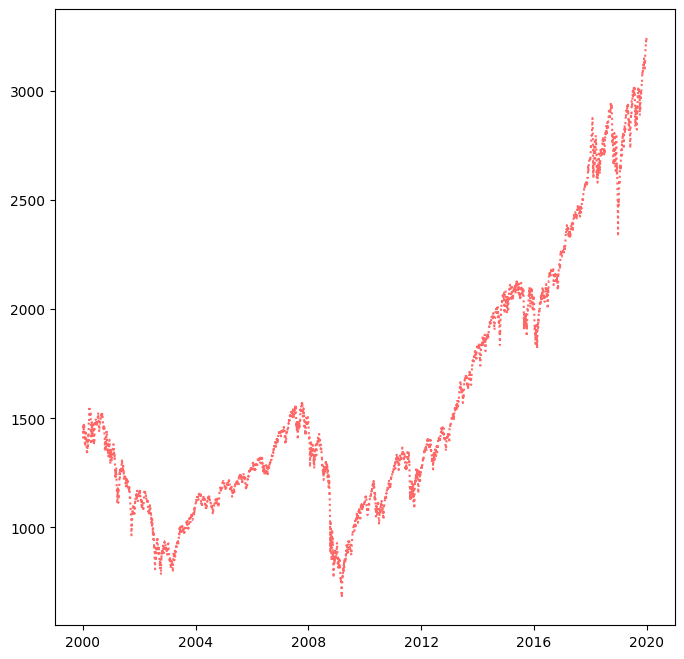

In [7]:
# Algunos parámetro del método plot
fig, ax = plt.subplots(figsize = (8,8))
ax.plot(Stocks.index,Stocks['avg'], linestyle = 'dotted', color = 'r', alpha = 0.6) #dotted, dashed, dashdot #o , v >
plt.show()

Supongamos que ahora queremos poner en perspetiva dos series, digamos el precio de cierre y el volumen transado. Si graficamos obtenemos lo siguiente

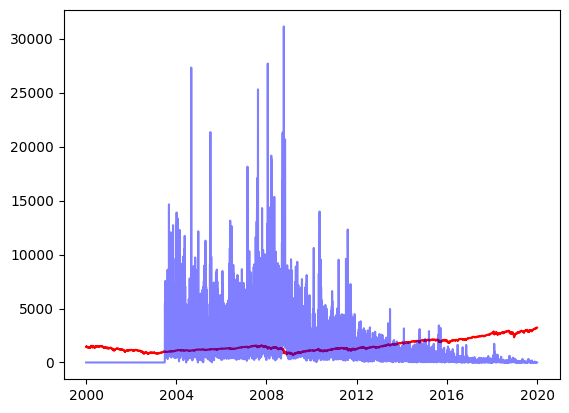

In [8]:
fig, ax = plt.subplots()
ax.plot(Stocks.index,Stocks['avg'], color = 'red')
ax.plot(Stocks.index,Stocks['vol'], color = 'blue', alpha = 0.5)
plt.show()

Claramente el gráfico anterior no ayuda a comprender ningún tipo de relación que puedan tener estas dos variables dado que al tener una escala de valores tan distinta, una parece una linea constante en 0, para ello tenemos dos alternativas:

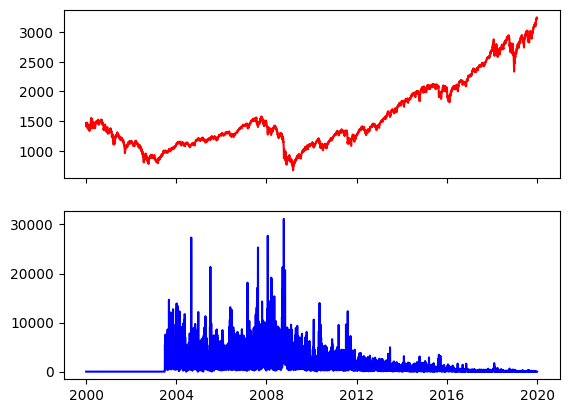

In [9]:
# Generar dos gráficos
fig, ax = plt.subplots(nrows = 2, ncols = 1, sharex = True)
ax[0].plot(Stocks.index,Stocks['avg'], color = 'red')
ax[1].plot(Stocks.index,Stocks['vol'], color = 'blue')
plt.show()

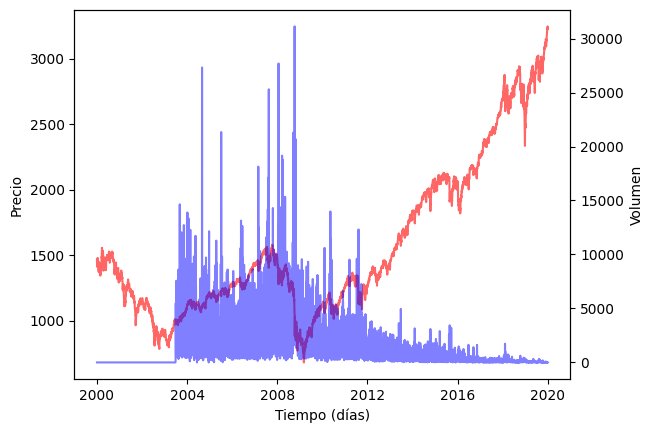

In [10]:
# Ambos gráficos  en la misma ventana, pero con escala propia
fig, ax = plt.subplots()
ax.plot(Stocks.index,Stocks['avg'], color = 'red',alpha = 0.6)
ax.set_xlabel('Tiempo (días)')
ax.set_ylabel('Precio')
ax2 = ax.twinx()
ax2.plot(Stocks.index,Stocks['vol'], color = 'blue', alpha = 0.5)
ax2.set_ylabel('Volumen')
plt.show()

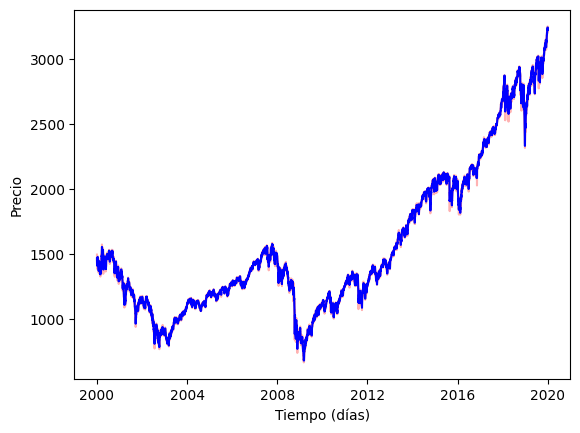

In [11]:
fig, ax = plt.subplots()
ax.plot(Stocks.index,Stocks['min'], color = 'red',alpha = 0.3)
ax.plot(Stocks.index,Stocks['max'], color = 'red', alpha = 0.3)
ax.plot(Stocks.index,Stocks['avg'], color = 'blue', alpha = 1)
ax.set_xlabel('Tiempo (días)')
ax.set_ylabel('Precio')
plt.show()

## Gráficos de barras, histogramas y variantes

Ahora que ya hemos jugado un poco con gráficos mediante el comando plot, entraremos a ver algunos gráficos super utilizados en data science y estadística como lo son los gráficos de barra e histogramas. Para ilustrar estos gráficos volveremos a los datos antes utilizados sobre animes

In [14]:
Animes = pd.read_excel('./Data/anime_dataset.xlsx')
Animes.head()

,anime_id,name,score,genre,type,episodes,rating,members
0,1,Cowboy Bebop,8.75,"Action, Award Winning, Sci-Fi",TV,26.0,R - 17+ (violence & profanity),1771505
1,5,Cowboy Bebop: Tengoku no Tobira,8.38,"Action, Sci-Fi",Movie,1.0,R - 17+ (violence & profanity),360978
2,6,Trigun,8.22,"Action, Adventure, Sci-Fi",TV,26.0,PG-13 - Teens 13 or older,727252
3,7,Witch Hunter Robin,7.25,"Action, Drama, Mystery, Supernatural",TV,26.0,PG-13 - Teens 13 or older,111931
4,8,Bouken Ou Beet,6.94,"Adventure, Fantasy, Supernatural",TV,52.0,PG - Children,15001


In [13]:
pip install openpyxl

In [15]:
Animes.groupby('type').agg('count')['episodes']

type
Movie      2475
Music      1482
ONA        1909
OVA        3246
Special    2033
TV         4458
UNKNOWN       1
Name: episodes, dtype: int64

In [ ]:
fig, ax = plt.subplots()
Animes_bar = Animes.groupby('type').agg('count')['episodes']
ax.bar(Animes_bar.index, Animes_bar, color = 'green')
ax.set_xlabel('Tipo')
ax.set_ylabel('Cantidad')
plt.show() 

Ya tenemos nuestro gráfico de barras. Ahora si tenemos una variable de la cual estamos en conocer su distribución, entonces necesitaremos hacer un histograma. Utilizando los mismos datos ilustraremos como se realiza

In [ ]:
fig, ax = plt.subplots()
ax.hist(Animes['score'], bins=50,cumulative = True, density=True, orientation='vertical') #density, cumulative
ax.set_xlabel('Rating')
ax.set_ylabel('Densidad')
plt.show()

Supongamos que tenemos otra variable que correponde a otro estilo de ranking (la cual crearemos a continuación) y queremos comprar sus distribuciones, entonces lo hacemos de la siguiente manera

In [ ]:
import numpy as np
#Animes['score2'] = Animes['members']*10/Animes['members'].max()+5
Animes['score2'] = np.log(Animes['score']) + 5
fig, ax = plt.subplots()
ax.hist(Animes['score'],bins = 100, density = True, cumulative=False ,color = 'red',alpha = 0.5, label = 'Rating 1')
ax.hist(Animes['score2'], bins = 50, density = True, cumulative=False, color = 'green', alpha = 0.5, label = 'Rating 2')
ax.legend(loc = 'upper right')
plt.show()

In [ ]:
#Gráfico de comparación de densidades, agrupando por type de Anime

Finalmente, el último gráfico de barras que revisaremos es uno conocido como stacked bar, que es útil para graficar las proporciones de ciertos atributos o caracteristicas para grupos de variables. Por ejemplo, crearemos un dataset que consiste en cantidad de niños, adolecentes, adultos y ancianos en cuatro países de latinoamerica Chile, Argentina, Ecuador y Colombia. Los datos son los siguientes:

In [ ]:
# Data
r = [0,1,2,3]
raw_data = {'Niños': [20, 30, 15, 10], 
            'Adolecentes': [25, 25, 5, 10],
            'Adultos': [20, 35, 50, 70],
            'Ancianos': [35, 10, 30, 10]}
names = ['Chile','Argentina','Ecuador','Colombia']
df = pd.DataFrame(raw_data, index=names)
df

In [ ]:
fig, ax = plt.subplots()
ax.bar(df.index, df['Niños'], label='Niños', color='#b5ffb9', edgecolor='white', width=0.85)
ax.bar(df.index, df['Adolecentes'], bottom=df['Niños'], color='#f9bc86', label='Adolecentes', edgecolor='white', width=0.85)
ax.bar(df.index, df['Adultos'], bottom=df['Niños'] + df['Adolecentes'], color='#a3acff', edgecolor='white', width=0.85, label='Adultos')
ax.bar(df.index, df['Ancianos'], bottom=df['Niños'] + df['Adolecentes'] + df['Adultos'], color='pink', edgecolor='white', width=0.85, label='Ancianos')
ax.set_xlabel('Países')
ax.set_ylabel('Proporciones')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

In [ ]:
colors = ['#b5ffb9', '#f9bc86', '#a3acff', 'pink']
fig, ax = plt.subplots()
for i, col in enumerate(df.columns):
  ax.bar(df.index, df[col], bottom=df.iloc[:, :i].sum(axis=1), 
         label=col, color=colors[i], edgecolor = 'white', width=0.85)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_xlabel('Pais')
ax.set_ylabel('Proporción');

## Gráficos de dispersión

Los gráficos de dispersión o scatterplot son muy útiles para descubrir relaciones entre variables o si estas presentan algún tipo de agrupamiento, entre otros. A continuación ilustraremos como construir dicho gráfico y algunas variantes. Partiremos utilizando los datos de Anime

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))
# Primero graficaremos el rating versus la cantidad de miembros
ax.plot(Animes['score'],Animes['members'],'.')
ax.set_xlabel('Members')
ax.set_ylabel('Rating')
plt.show()

In [ ]:
Animes.head()

In [ ]:
fig, ax = plt.subplots(figsize=(8,8))
# Primero graficaremos el rating versus la cantidad de miembros
ax.scatter(Animes['score'],Animes['members'],marker = '.', s = Animes['episodes'], alpha=0.5)
ax.set_xlabel('Members')
ax.set_ylabel('Rating')
plt.show()

In [ ]:
# Ahora rating versus cantidad de capítulos
fig, ax = plt.subplots()
ax.scatter(Animes['episodes'],Animes['score'],marker = '+')
ax.set_xlabel('Nro de Cap')
ax.set_ylabel('Rating')
plt.show()

In [ ]:
# Ahora podemos hacer algo un poco más sofisticado, haciendo un gráfico rating vs miembros, donde el tamaño
# del punto sea dado por episodes
# Como añadir escala de color?
fig, ax = plt.subplots(figsize = (8,8))
ax.scatter(Animes['members'],Animes['score'],c = Animes['episodes'], s = Animes['episodes'], alpha = 0.2, marker = 'o')
ax.set_xlabel('Members')
ax.set_ylabel('Rating')
plt.show()

## Boxplot

El diagrama de caja o boxplot es un gráfico muy utilizado con distintos propositos, dado que el muestra de manera gráfica y utilizando indicadores de posición, la distribución y dispersión de una variable. A continuación mostraremos como graficar un boxplot así como también algunas variantes cuando son varias variables.

In [ ]:
fig, ax = plt.subplots()
ax.boxplot(Animes['score'], labels = ['score'], vert=True, showfliers= False, whis = 3) # showfliers = False, vert = False
ax.set_ylabel('Valores')
plt.show()

In [ ]:
import numpy as np
fig, ax = plt.subplots()
Animes['Epi_norm'] = np.random.rand(15604) * 10
ax.boxplot([Animes['score'],Animes['Epi_norm']], labels = ['Rating','Episodes'])
ax.set_ylabel('Valores')
plt.show()

Para más opciones, como hacer multiples boxplot que además estan separados por categorias se puede realizar (mostraremos a continuación), pero es mucho más sencillo utilizando otra librería para generar graficos llamada seaborn.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

data_1 = [[1,2,5], [5,7,2,2,5], [7,2,5]]
data_2 = [[6,4,2], [1,2,5,3,2], [2,3,5,1]]

ticks = ['A', 'B', 'C']

fig, ax = plt.subplots()
ax.boxplot(data_1, label=ticks)
ax.boxplot(data_2, label=ticks)
plt.show()

In [ ]:
fig, ax = plt.subplots()
ax.boxplot(data_1, positions=np.array(range(len(data_1)))*2.0-0.4, sym='', widths=0.6)
ax.boxplot(data_2, positions=np.array(range(len(data_2)))*2.0+0.4, sym='', widths=0.6)
plt.xticks(range(0, len(ticks) * 2, 2), ticks)
plt.show()

Si hacemos lo mismo pero con seaborn, tendremos lo siguiente

In [ ]:
import seaborn as sb
df = pd.DataFrame({'Group':['A','A','A','B','C','B','B','C','A','C'],\
                  'Apple':np.random.rand(10),'Orange':np.random.rand(10)})
display(df)
dd=pd.melt(df,id_vars=['Group'],value_vars=['Apple','Orange'],var_name='fruits')
display(dd)
sb.boxplot(x='Group',y='value',data=dd,hue='fruits')

In [ ]:
import plotly.express as px

In [ ]:
fig, ax = plt.subplots(figsize = (8,8))
ax.scatter(Animes['members'],Animes['score'],c = Animes['episodes'], s = Animes['episodes'], alpha = 0.2, marker = 'o')
ax.set_xlabel('Members')
ax.set_ylabel('Rating')
plt.show()

In [ ]:
df = px.data.iris()
fig = px.scatter(Animes, x="members", y="score", color="episodes",
                 size='episodes', hover_data=['members'])
fig.show()

## Laboratorio

Con el dataset de wine quality realice lo siguiente:

 - Cargue los datos utilizando pandas. Obtenga las dimensiones de los datos y tipos de variable.
 - Revise si el dataset posee datos faltantes. En caso de existir, realice imputación de estos datos u otra técnica vista en clase.
 - Realice estadísticas descriptivas para las variables alcohol y fixed acidity.
 - Al variable a explicar es quality, y por ello genere un histograma para visualizar la distribución de los vinos según calidad
 - Realice scatterplots entre las variables fixed acidity y volatile acidity, así como también entre pH y alcohol. ¿Qué observa? Realice algunos scatterplot entre la variable quality y otras a su elección, ¿Qué observa?
 - Realice boxplots donde cada caja corresponde a vinos de una cierta calidad, y los valores correspondan a pH y alcohol (pueden ser dos boxplot, uno por cada variable). Describa lo que observa.



In [ ]:
import pandas as pd
wine = pd.read_excel('./Data/WineQT.xlsx')
wine.head()